# freqk_gr — ΔAF analysis (field vs seed-mix founder)

Pipeline:
1. Load seed-mix k-mer counts → founder baseline AF per variant  
2. Load field samples (lean) → compute Δp = field AF − baseline  
3. Pivot to **wide matrix** (variants × samples) of Δp  
4. Sample a subset for quick EDA without crashing the notebook  
5. Analysis: QC, temporal trajectories, per-plot comparisons

In [25]:
pwd

'/Users/tatiana/Documents_new/freqk_gr/summaries'

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS = Path("/Users/tatiana/Documents_new/freqk_gr/results")
DATA    = Path("/Users/tatiana/Documents_new/freqk_gr/data")
K = 31

# How many variants to sample for quick EDA plots (set None to use all)
N_SAMPLE = 50_000


## 1. Discover files

In [27]:
af_files = sorted(RESULTS.glob(f"*/*/k{K}/*.counts_by_allele.k{K}.tsv"))
sm_files = sorted(RESULTS.glob(f"seedmix/*/k{K}/*.counts_by_allele.k{K}.tsv"))

# Exclude seed-mix from field files (they live under results/seedmix/)
af_files = [f for f in af_files if "seedmix" not in f.parts]

print(f"Field samples : {len(af_files)}")
for f in af_files:
    print(" ", f.parent.parent.name)
print(f"\nSeed mix reps : {len(sm_files)}")
for f in sm_files:
    print(" ", f.parent.parent.name)


Field samples : 49
  MLFH040120200206
  MLFH040220200212
  MLFH040320180306
  MLFH040320180321
  MLFH040320190208
  MLFH040320190221
  MLFH040320200206
  MLFH040420180306
  MLFH040420180321
  MLFH040520180306
  MLFH040520180321
  MLFH040520190208
  MLFH040520190221
  MLFH040520200206
  MLFH040620180306
  MLFH040620180321
  MLFH040620190208
  MLFH040620190221
  MLFH040620200206
  MLFH040720180306
  MLFH040720180321
  MLFH040720190208
  MLFH040720190221
  MLFH040720200212
  MLFH040820180306
  MLFH040820180321
  MLFH040820190208
  MLFH040820190221
  MLFH040820200212
  MLFH040920180306
  MLFH040920180321
  MLFH040920190208
  MLFH040920190221
  MLFH040920200206
  MLFH041020180306
  MLFH041020180321
  MLFH041020190208
  MLFH041020190221
  MLFH041020200206
  MLFH041120180306
  MLFH041120180321
  MLFH041120190208
  MLFH041120190221
  MLFH041120200212
  MLFH041220180306
  MLFH041220180321
  MLFH041220190208
  MLFH041220190221
  MLFH041220200212

Seed mix reps : 8
  SEEDMIX_S1
  SEEDMIX_S2
  SEE

## 2. Seed-mix baseline

Average AF across S1–S8 per variant.  
Infinite-population assumption for the founder pool — just take the mean.  
Require coverage in ≥ `MIN_SM_REPS` of the 8 replicates.

In [28]:
MIN_SM_REPS = 4   # out of 8

def load_counts(path):
    """Minimal loader: returns DataFrame with ref|alt counts + variant_idx."""
    df = pd.read_csv(path, sep="|", header=None, names=["ref","alt"], dtype=float)
    df[["ref","alt"]] = df[["ref","alt"]].fillna(0).astype(int)
    df["variant_idx"] = df.index
    total = df["ref"] + df["alt"]
    df["af"] = np.where(total > 0, df["alt"] / total, np.nan)
    df["coverage_kmers"] = total
    return df

if not sm_files:
    raise RuntimeError("No seed-mix results yet — run: python scripts/launch_seedmix.py")

sm_dfs = []
for f in sm_files:
    tmp = load_counts(f)
    tmp["replicate"] = f.parent.parent.name   # SEEDMIX_S1 …
    sm_dfs.append(tmp[tmp["coverage_kmers"] > 0][["variant_idx","replicate","af"]])

sm_all = pd.concat(sm_dfs, ignore_index=True)

sm_baseline = (
    sm_all.groupby("variant_idx")["af"]
    .agg(af_sm="mean", af_sm_std="std", n_sm_reps="count")
    .reset_index()
)
sm_baseline = sm_baseline[sm_baseline["n_sm_reps"] >= MIN_SM_REPS].copy()

print(f"Seed-mix baseline variants (≥{MIN_SM_REPS}/8 reps covered): {len(sm_baseline):,}")
print(f"Mean cross-replicate std: {sm_baseline['af_sm_std'].mean():.4f}")
sm_baseline.head()


Seed-mix baseline variants (≥4/8 reps covered): 2,132,749
Mean cross-replicate std: 0.0331


,variant_idx,af_sm,af_sm_std,n_sm_reps
0,0,0.000000,0.000000,8
1,1,0.209257,0.124444,8
2,2,0.000000,0.000000,8
3,3,0.011404,0.016141,8
4,4,0.003289,0.009304,8


In [29]:
sm_baseline

,variant_idx,af_sm,af_sm_std,n_sm_reps
0,0,0.000000,0.000000,8
1,1,0.209257,0.124444,8
2,2,0.000000,0.000000,8
3,3,0.011404,0.016141,8
4,4,0.003289,0.009304,8
...,...,...,...,...
2154610,2187902,0.005214,0.009670,8
2154611,2187903,0.026872,0.022418,8
2154612,2187904,0.065560,0.045089,8
2154613,2187905,0.017555,0.031819,8


## 3. Load field samples (lean)

Load only the columns we need; filter immediately to variants that have a  
seed-mix baseline *and* are covered in this sample.  
This keeps the tall DataFrame small.

In [30]:
def parse_sample_id(sample_id):
    site = sample_id[4:6]
    plot = sample_id[6:8]
    date = sample_id[8:16]
    year = sample_id[8:12]
    return site, plot, date, year

sm_idx = set(sm_baseline["variant_idx"])  # fast lookup set

rows = []
for path in af_files:
    sid = path.parent.parent.name
    site, plot, date, year = parse_sample_id(sid)
    df = load_counts(path)
    # keep only variants with seed-mix baseline AND k-mer coverage
    df = df[(df["coverage_kmers"] > 0) & (df["variant_idx"].isin(sm_idx))].copy()
    df["sample_id"] = sid
    df["site"]      = site
    df["plot"]      = plot
    df["date"]      = pd.to_datetime(date, format="%Y%m%d")
    df["year"]      = year
    rows.append(df[["variant_idx","sample_id","site","plot","date","year","af","coverage_kmers"]])
    print(f"  {sid}: {len(df):,} covered variants with baseline")

df_tall = pd.concat(rows, ignore_index=True)
print(f"\nTall DataFrame: {df_tall.shape}  ({df_tall['variant_idx'].nunique():,} unique variants, {df_tall['sample_id'].nunique()} samples)")


  MLFH040120200206: 1,993,681 covered variants with baseline
  MLFH040220200212: 2,050,785 covered variants with baseline
  MLFH040320180306: 2,068,108 covered variants with baseline
  MLFH040320180321: 2,079,052 covered variants with baseline
  MLFH040320190208: 2,057,299 covered variants with baseline
  MLFH040320190221: 2,047,601 covered variants with baseline
  MLFH040320200206: 1,977,171 covered variants with baseline
  MLFH040420180306: 2,065,605 covered variants with baseline
  MLFH040420180321: 2,059,653 covered variants with baseline
  MLFH040520180306: 1,914,422 covered variants with baseline
  MLFH040520180321: 1,987,150 covered variants with baseline
  MLFH040520190208: 2,013,990 covered variants with baseline
  MLFH040520190221: 2,008,566 covered variants with baseline
  MLFH040520200206: 1,974,532 covered variants with baseline
  MLFH040620180306: 1,895,815 covered variants with baseline
  MLFH040620180321: 1,999,929 covered variants with baseline
  MLFH040620190208: 2,01

## 4. Join sample metadata

In [31]:
meta = pd.read_csv(DATA / "samples_data_fix57.csv", usecols=[
    "sampleid","flowerscollected","generation","fix_57_generation",
    "coverage","weighted_mean_coverage","usesample"
]).rename(columns={"sampleid":"sample_id"})

df_tall = df_tall.merge(meta, on="sample_id", how="left")
df_tall["N"]      = df_tall["flowerscollected"]
df_tall["min_af"] = 1 / df_tall["N"]

print(df_tall.dtypes)
df_tall.head()


variant_idx                        int64
sample_id                         object
site                              object
plot                              object
date                      datetime64[ns]
year                              object
af                               float64
coverage_kmers                     int64
flowerscollected                   int64
generation                         int64
coverage                         float64
usesample                           bool
weighted_mean_coverage           float64
fix_57_generation                  int64
N                                  int64
min_af                           float64
dtype: object


,variant_idx,sample_id,site,plot,date,year,af,coverage_kmers,flowerscollected,generation,coverage,usesample,weighted_mean_coverage,fix_57_generation,N,min_af
0,0,MLFH040120200206,04,01,2020-02-06,2020,0.0,8,40,3,5.276738,True,5.276738,3,40,0.025
1,2,MLFH040120200206,04,01,2020-02-06,2020,0.0,3,40,3,5.276738,True,5.276738,3,40,0.025
2,3,MLFH040120200206,04,01,2020-02-06,2020,0.0,11,40,3,5.276738,True,5.276738,3,40,0.025
3,4,MLFH040120200206,04,01,2020-02-06,2020,0.0,2,40,3,5.276738,True,5.276738,3,40,0.025
4,5,MLFH040120200206,04,01,2020-02-06,2020,0.0,2,40,3,5.276738,True,5.276738,3,40,0.025


## 5. Compute Δp = field AF − seed-mix baseline

Join baseline per `variant_idx`, then compute the allele-frequency shift.

In [32]:
df_tall = df_tall.merge(
    sm_baseline[["variant_idx","af_sm","af_sm_std","n_sm_reps"]],
    on="variant_idx", how="left"
)
df_tall["delta_p"]     = df_tall["af"] - df_tall["af_sm"]
df_tall["abs_delta_p"] = df_tall["delta_p"].abs()

print(f"delta_p range: {df_tall['delta_p'].min():.3f} to {df_tall['delta_p'].max():.3f}")
print(f"Mean |Δp|: {df_tall['abs_delta_p'].mean():.4f}")
df_tall[["variant_idx","sample_id","af","af_sm","delta_p"]].head()


delta_p range: -1.000 to 1.000
Mean |Δp|: 0.0898


,variant_idx,sample_id,af,af_sm,delta_p
0,0,MLFH040120200206,0.0,0.000000,0.000000
1,2,MLFH040120200206,0.0,0.000000,0.000000
2,3,MLFH040120200206,0.0,0.011404,-0.011404
3,4,MLFH040120200206,0.0,0.003289,-0.003289
4,5,MLFH040120200206,0.0,0.002660,-0.002660


## 6. Wide Δp matrix  (variants × samples)

Rows = `variant_idx`, columns = `sample_id`, values = `delta_p`.  
This is the primary object for downstream analysis.

In [33]:
dp_wide = df_tall.pivot_table(
    index="variant_idx", columns="sample_id", values="delta_p"
)
dp_wide.columns.name = None

print(f"Wide matrix shape: {dp_wide.shape}")
print(f"Memory: {dp_wide.memory_usage(deep=True).sum() / 1e6:.1f} MB")
dp_wide.head()


Wide matrix shape: (2125343, 49)
Memory: 850.1 MB


,MLFH040120200206,MLFH040220200212,MLFH040320180306,MLFH040320180321,MLFH040320190208,MLFH040320190221,MLFH040320200206,MLFH040420180306,MLFH040420180321,MLFH040520180306,...,MLFH041120180306,MLFH041120180321,MLFH041120190208,MLFH041120190221,MLFH041120200212,MLFH041220180306,MLFH041220180321,MLFH041220190208,MLFH041220190221,MLFH041220200212
variant_idx,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,0.000000,NaN
1,NaN,NaN,NaN,0.527586,NaN,-0.209257,0.790743,NaN,-0.209257,-0.209257,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.209257,NaN,NaN,NaN
2,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,-0.011404,...,-0.011404,-0.011404,-0.011404,-0.011404,NaN,NaN,-0.011404,-0.011404,-0.011404,-0.011404
4,-0.003289,-0.003289,-0.003289,-0.003289,-0.003289,-0.003289,NaN,-0.003289,-0.003289,-0.003289,...,-0.003289,-0.003289,-0.003289,-0.003289,-0.003289,-0.003289,-0.003289,0.330044,0.246711,-0.003289


In [34]:
# Drop rows where every value is either NaN or 0
mask = (dp_wide.fillna(0) != 0).any(axis=1)
dp_wide = dp_wide[mask]
print(f"After dropping all-NaN/all-zero rows: {dp_wide.shape}")

After dropping all-NaN/all-zero rows: (1868982, 49)


In [43]:
dp_wide.to_csv('delta_p.csv')

In [45]:
pwd

'/Users/tatiana/Documents_new/freqk_gr/summaries'

In [52]:
# ── Annotate dp_wide with CHROM, POS, var_type, sv_size ─────────────────
# Use the variant_positions file saved by the pipeline (col 1=chrom, col 2=pos).
# Rows correspond 1-to-1 with counts_by_allele rows → correct mapping after dedup.
# Use any completed sample's file (they all share the same VCF/index).

pos_file = next(RESULTS.glob(f"*/*/k{K}/*.variant_positions.k{K}.tsv"), None)
if pos_file is None:
    raise FileNotFoundError(
        "No variant_positions file found. Re-run the pipeline — "
        "the updated run_freqk.sh now saves this file before cleanup."
    )
print(f"Using positions from: {pos_file}")

vcf_pos = pd.read_csv(
    pos_file, header=None, names=["chrom", "pos"],
    sep=",", dtype={"chrom": str, "pos": int}
)
vcf_pos.index.name = "variant_idx"
vcf_pos = vcf_pos.reset_index()

# Derive variant type and SV size from the VCF REF/ALT
import gzip
VCF = Path("/home/tbellagio/scratch/pang/sv_panel/merge_vcfs/panel.snp_ins_del.vcf.gz")

# Read only CHROM, POS, REF, ALT from the VCF, build a lookup by (chrom, pos)
vcf_lookup = {}
with gzip.open(VCF, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.split("\t", 5)
        key = (parts[0], int(parts[1]))
        if key not in vcf_lookup:   # keep first occurrence
            vcf_lookup[key] = (parts[3], parts[4].strip())

ref_len = vcf_pos.apply(lambda r: len(vcf_lookup.get((r.chrom, r.pos), ("",""))[0]), axis=1)
alt_len = vcf_pos.apply(lambda r: len(vcf_lookup.get((r.chrom, r.pos), ("",""))[1]), axis=1)

vcf_pos["var_type"] = "SNP"
vcf_pos.loc[alt_len > ref_len, "var_type"] = "INS"
vcf_pos.loc[ref_len > alt_len, "var_type"] = "DEL"
vcf_pos["sv_size"] = (alt_len - ref_len).abs()

print(f"Positions loaded: {len(vcf_pos):,}")
print(vcf_pos["var_type"].value_counts())
vcf_pos.head()


var_type
SNP    1501123
DEL     201092
INS     166767
Name: count, dtype: int64
(1868982, 51)


MLFH040120200206  MLFH040220200212  MLFH040320180306  \
chrom pos                                                         
Chr1  64                NaN               NaN               NaN   
      83          -0.011404         -0.011404         -0.011404   
      92          -0.003289         -0.003289         -0.003289   
      121         -0.002660         -0.002660         -0.002660   
      121         -0.006458         -0.006458         -0.006458   

           MLFH040320180321  MLFH040320190208  MLFH040320190221  \
chrom pos                                                         
Chr1  64           0.527586               NaN         -0.209257   
      83          -0.011404         -0.011404         -0.011404   
      92          -0.003289         -0.003289         -0.003289   
      121         -0.002660         -0.002660         -0.002660   
      121         -0.006458         -0.006458         -0.006458   

           MLFH040320200206  MLFH040420180306  MLFH040420180321  \
chrom pos                                                         
Chr1  64           0.790743               NaN         -0.209257   
      83          -0.011404         -0.011404         -0.011404   
      92                NaN         -0.003289         -0.003289   
      121          0.997340          0.497340         -0.002660   
      121         -0.006458         -0.006458         -0.006458   

           MLFH040520180306  ...  MLFH041120190208  MLFH041120190221  \
chrom pos                    ...                                       
Chr1  64          -0.209257  ...               NaN               NaN   
      83          -0.011404  ...         -0.011404         -0.011404   
      92          -0.003289  ...         -0.003289         -0.003289   
      121         -0.002660  ...         -0.002660         -0.002660   
      121         -0.006458  ...         -0.006458         -0.006458   

           MLFH041120200212  MLFH041220180306  MLFH041220180321  \
chrom pos                                                         
Chr1  64                NaN               NaN         -0.209257   
      83                NaN               NaN         -0.011404   
      92          -0.003289         -0.003289         -0.003289   
      121         -0.002660         -0.002660         -0.002660   
      121         -0.006458         -0.006458         -0.006458   

           MLFH041220190208  MLFH041220190221  MLFH041220200212  var_type  \
chrom pos                                                                   
Chr1  64                NaN               NaN               NaN       SNP   
      83          -0.011404         -0.011404         -0.011404       SNP   
      92           0.330044          0.246711         -0.003289       SNP   
      121          0.247340          0.164007         -0.002660       SNP   
      121         -0.006458         -0.006458         -0.006458       SNP   

           sv_size  
chrom pos           
Chr1  64         0  
      83         0  
      92         0  
      121        0  
      121        0  

[5 rows x 51 columns]

In [53]:
# Join positions onto dp_wide
dp_annotated = (
    dp_wide
    .reset_index()
    .merge(vcf_pos, on="variant_idx", how="left")
    .set_index(["chrom", "pos"])
    .drop(columns="variant_idx")
)

print(f"dp_annotated shape: {dp_annotated.shape}")
print(f"Chromosomes: {sorted(dp_annotated.reset_index()['chrom'].unique())}")
dp_annotated.head()


MLFH040120200206  MLFH040220200212  MLFH040320180306  \
chrom pos                                                             
Chr1  1680            -0.002291         -0.002291         -0.002291   
      4295            -0.149035         -0.149035         -0.149035   
      8692            -0.016647         -0.016647         -0.016647   
      8692            -0.009206         -0.009206         -0.009206   
      8894            -0.047419          0.129724          0.077581   
...                         ...               ...               ...   
Chr2  8307980         -0.011641         -0.011641         -0.011641   
      8308948          0.000000          0.000000          0.000000   
      8319736          0.164244         -0.002422          0.078223   
      8320067         -0.050828         -0.050828         -0.050828   
      8331072         -0.004743         -0.004743          0.101318   

               MLFH040320180321  MLFH040320190208  MLFH040320190221  \
chrom pos                                                             
Chr1  1680            -0.002291         -0.002291         -0.002291   
      4295            -0.149035         -0.149035         -0.149035   
      8692            -0.016647         -0.016647         -0.016647   
      8692            -0.009206         -0.009206         -0.009206   
      8894            -0.047419         -0.047419         -0.047419   
...                         ...               ...               ...   
Chr2  8307980         -0.011641         -0.011641         -0.011641   
      8308948          0.000000          0.000000          0.000000   
      8319736         -0.002422         -0.002422          0.197578   
      8320067         -0.050828         -0.050828         -0.050828   
      8331072         -0.004743         -0.004743         -0.004743   

               MLFH040320200206  MLFH040420180306  MLFH040420180321  \
chrom pos                                                             
Chr1  1680             0.091827         -0.002291         -0.002291   
      4295            -0.149035         -0.149035         -0.149035   
      8692            -0.016647         -0.016647         -0.016647   
      8692            -0.009206         -0.009206         -0.009206   
      8894             0.275498          0.256929         -0.047419   
...                         ...               ...               ...   
Chr2  8307980         -0.011641         -0.011641         -0.011641   
      8308948          0.000000          0.000000          0.000000   
      8319736          0.664244         -0.002422         -0.002422   
      8320067         -0.050828         -0.050828         -0.050828   
      8331072         -0.004743         -0.004743         -0.004743   

               MLFH040520180306  ...  MLFH041120190208  MLFH041120190221  \
chrom pos                        ...                                       
Chr1  1680            -0.002291  ...         -0.002291         -0.002291   
      4295            -0.149035  ...         -0.149035         -0.149035   
      8692            -0.016647  ...         -0.016647         -0.016647   
      8692            -0.009206  ...         -0.009206          0.145794   
      8894            -0.047419  ...         -0.047419         -0.047419   
...                         ...  ...               ...               ...   
Chr2  8307980         -0.011641  ...         -0.011641         -0.011641   
      8308948          0.000000  ...          0.000000          0.000000   
      8319736          0.497578  ...          0.747578         -0.002422   
      8320067         -0.050828  ...         -0.050828         -0.050828   
      8331072         -0.004743  ...         -0.004743         -0.004743   

               MLFH041120200212  MLFH041220180306  MLFH041220180321  \
chrom pos                                                             
Chr1  1680             0.167922         -0.002291         -0.002291   
      4295            -0.149035         -

In [55]:
dp_annotated.index

MultiIndex([('Chr1',      64),
            ('Chr1',      83),
            ('Chr1',      92),
            ('Chr1',     121),
            ('Chr1',     121),
            ('Chr1',     133),
            ('Chr1',     139),
            ('Chr1',     179),
            ('Chr1',     189),
            ('Chr1',     200),
            ...
            ('Chr2', 8332049),
            ('Chr2', 8332071),
            ('Chr2', 8332071),
            ('Chr2', 8332071),
            ('Chr2', 8332071),
            ('Chr2', 8332071),
            ('Chr2', 8332071),
            ('Chr2', 8332078),
            ('Chr2', 8332080),
            ('Chr2', 8332087)],
           names=['chrom', 'pos'], length=1868982)

## 7. Sample for quick EDA

Draw `N_SAMPLE` random variants so plots render fast.  
Set `N_SAMPLE = None` at the top to use the full matrix.

In [36]:
rng = np.random.default_rng(42)

if N_SAMPLE and N_SAMPLE < len(dp_wide):
    sample_idx = rng.choice(dp_wide.index, size=N_SAMPLE, replace=False)
    dp_sample  = dp_wide.loc[sample_idx]
    tall_sample = df_tall[df_tall["variant_idx"].isin(sample_idx)]
    print(f"Sampled {N_SAMPLE:,} / {len(dp_wide):,} variants for EDA")
else:
    dp_sample   = dp_wide
    tall_sample = df_tall
    print("Using full matrix for EDA")


Sampled 50,000 / 1,868,982 variants for EDA


## 8. QC

In [37]:
# Coverage and below-min-AF summary per sample
qc = (
    df_tall.groupby("sample_id")
    .apply(lambda x: pd.Series({
        "n_variants":   len(x),
        "mean_cov":     x["coverage_kmers"].mean(),
        "pct_low_cov":  100 * (x["coverage_kmers"] < 5).mean(),
        "mean_abs_dp":  x["abs_delta_p"].mean(),
    }))
    .reset_index()
)
print(qc.to_string(index=False))


       sample_id  n_variants   mean_cov  pct_low_cov  mean_abs_dp
MLFH040120200206   1993681.0  63.979710     7.028206     0.093451
MLFH040220200212   2050785.0  96.304086     3.533135     0.078241
MLFH040320180306   2068108.0 127.957183     2.262068     0.071318
MLFH040320180321   2079052.0 135.667925     1.962866     0.057411
MLFH040320190208   2057299.0 109.963498     2.786566     0.078966
MLFH040320190221   2047601.0  93.181015     4.023538     0.075758
MLFH040320200206   1977171.0  67.867555     6.742866     0.113625
MLFH040420180306   2065605.0 107.321327     3.011563     0.069569
MLFH040420180321   2059653.0  92.723711     3.911047     0.064954
MLFH040520180306   1914422.0  45.140005    10.965189     0.089916
MLFH040520180321   1987150.0  55.917725     8.418791     0.078023
MLFH040520190208   2013990.0  69.992732     6.272871     0.089507
MLFH040520190221   2008566.0  67.185601     6.772742     0.087721
MLFH040520200206   1974532.0  62.058637     7.425557     0.111256
MLFH040620

/var/folders/89/m0n7cpqn6153r2j98t2n5yq40000gr/T/ipykernel_36145/4294870263.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


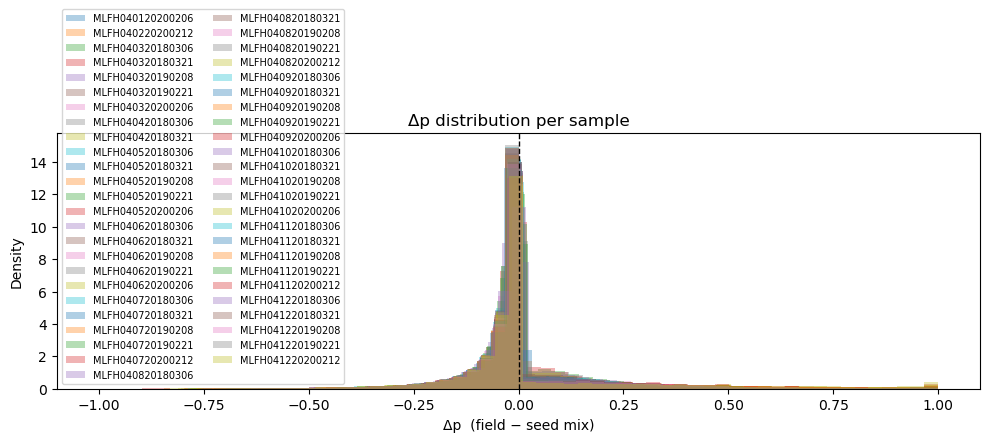

In [38]:
# Δp distribution per sample (sampled variants)
fig, ax = plt.subplots(figsize=(10, 4))
for sid, grp in tall_sample.groupby("sample_id"):
    grp["delta_p"].dropna().plot.hist(bins=60, alpha=0.35, density=True, label=sid, ax=ax)
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Δp  (field − seed mix)")
ax.set_ylabel("Density")
ax.set_title("Δp distribution per sample")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 9. Δp over time — site 04

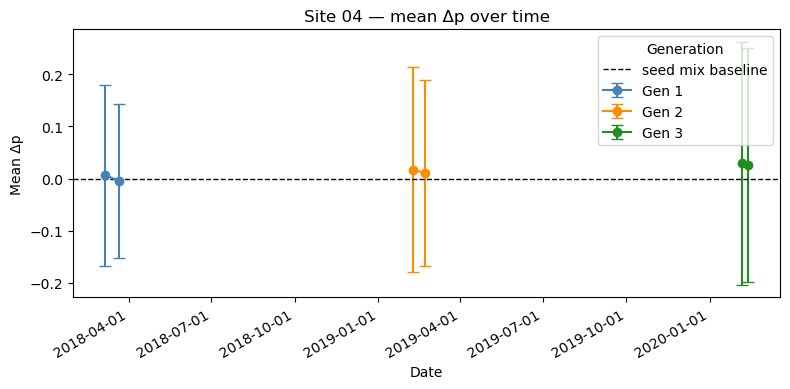

In [39]:
site04 = tall_sample[tall_sample["site"] == "04"].copy()

# mean Δp per date (averaged across variants and plots)
summary = (
    site04.groupby(["date","generation"])["delta_p"]
    .agg(mean="mean", std="std")
    .reset_index()
)

gen_colors = {1:"steelblue", 2:"darkorange", 3:"forestgreen"}

fig, ax = plt.subplots(figsize=(8, 4))
for gen, grp in summary.groupby("generation"):
    ax.errorbar(grp["date"], grp["mean"], yerr=grp["std"],
                fmt="o-", capsize=4, color=gen_colors.get(gen,"gray"),
                label=f"Gen {int(gen)}")
ax.axhline(0, color="black", lw=1, ls="--", label="seed mix baseline")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Δp")
ax.set_title("Site 04 — mean Δp over time")
ax.legend(title="Generation")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 10. Per-plot Δp comparison — site 04

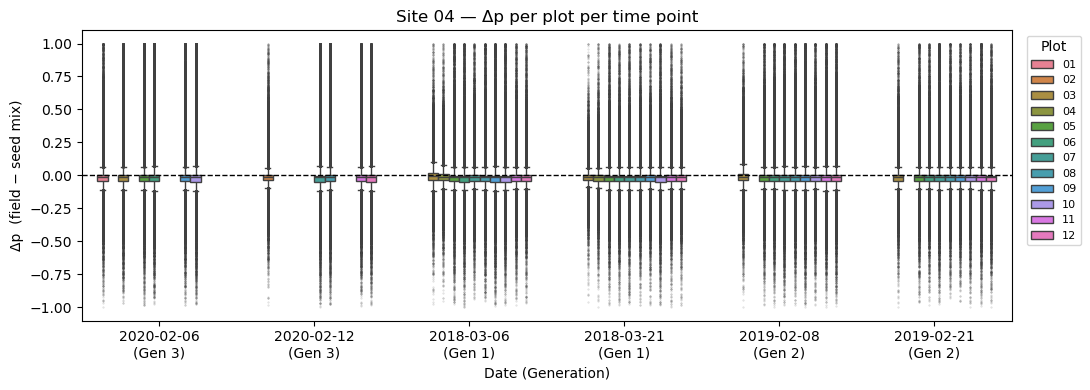

In [40]:
site04["date_gen"] = site04.apply(
    lambda r: (
        f"{r['date'].strftime('%Y-%m-%d')}\n(Gen {int(r['generation'])})"
        if pd.notna(r["generation"]) else r["date"].strftime("%Y-%m-%d")
    ), axis=1
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(
    data=site04, x="date_gen", y="delta_p", hue="plot",
    ax=ax, flierprops=dict(marker=".", alpha=0.2, markersize=1)
)
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Date (Generation)")
ax.set_ylabel("Δp  (field − seed mix)")
ax.set_title("Site 04 — Δp per plot per time point")
ax.legend(title="Plot", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 11. Filter to variants that changed

Keep only variants where `|Δp| > threshold` in ≥ 1 sample.  
Threshold = `max(1/N, DELTA_MIN)` — respects the per-sample flower-count noise floor.

In [41]:
DELTA_MIN = 0.05

df_tall["threshold"] = np.maximum(df_tall["min_af"].fillna(DELTA_MIN), DELTA_MIN)
df_tall["is_changed"] = df_tall["abs_delta_p"] > df_tall["threshold"]

changed_idx = (
    df_tall.groupby("variant_idx")["is_changed"].any()
)
changed_idx = changed_idx[changed_idx].index

print(f"Total tested variants : {df_tall['variant_idx'].nunique():,}")
print(f"Changed in ≥1 sample  : {len(changed_idx):,}  ({100*len(changed_idx)/df_tall['variant_idx'].nunique():.1f}%)")

dp_changed = dp_wide.loc[dp_wide.index.isin(changed_idx)]
print(f"Changed wide matrix   : {dp_changed.shape}")


Total tested variants : 2,125,343
Changed in ≥1 sample  : 1,556,161  (73.2%)
Changed wide matrix   : (1556161, 49)


In [42]:
# Save for downstream use
out_path = RESULTS / "site04_delta_p.tsv"
# melt changed wide matrix back to tall for saving
dp_changed.reset_index().melt(id_vars="variant_idx", var_name="sample_id", value_name="delta_p")    .dropna(subset=["delta_p"])    .to_csv(out_path, sep="\t", index=False)
print(f"Saved → {out_path}")


Saved → /Users/tatiana/Documents_new/freqk_gr/results/site04_delta_p.tsv
